## __`rioxarray` Knowledge Check__

Our original data was in the file format of .tif. These files, GeoTiffs, are very useful as they are images that retain geographic attributes, like projections and coordinates. We did a lot of manipulation with our data, but we would also like to be able to save our manipulated data as a GeoTiff so we have it for later, or so we can bring it into other programs like ArcGIS Pro.

In this knowledge check you will:
1. __Clip__ the data to a smaller area of interest (AOI), someplace other than the Luecke property! 
    * Where did you choose?
    * What type of land covers are there?
3. __Display__ your AOI using a different, [false-color](https://www.usgs.gov/media/images/common-landsat-band-combinations), band combination using B5 as one of the selected bands.
    * Why did you choose this combination?
    * Does it [show you anything you couldn't see before](https://earthobservatory.nasa.gov/features/FalseColor) in the true-color image?
2. __Calculate__ a [Normalized Difference Water Index (NDWI)](https://geoai.au/ndwi-normalized-difference-water-index-with-remote-sensing/) for your clipped raster.
3. __Display__ the NDWI image using a different [color map (cmap)](https://matplotlib.org/stable/users/explain/colors/colormaps.html) than the NDVI image.
    * What cmap did you choose, and why?
4. __[Export](https://corteva.github.io/rioxarray/stable/examples/convert_to_raster.html)__ the NDWI image as a GeoTiff so that it can be used later.

The code to load the data has been included below for convenience.

In [33]:
import rioxarray as rxr
import os
import xarray as xr

data_src = os.path.expanduser("~/ASC_students/ryan/advanced_packages/data/")

band_files = [f"{data_src}LC09_L2SP_026039_20251105_20251106_02_T1_SR_B2.TIF", f"{data_src}LC09_L2SP_026039_20251105_20251106_02_T1_SR_B3.TIF", f"{data_src}LC09_L2SP_026039_20251105_20251106_02_T1_SR_B4.TIF", f"{data_src}LC09_L2SP_026039_20251105_20251106_02_T1_SR_B5.TIF"]
band_names = ['B2', 'B3', 'B4', 'B5'] # B2 is blue, B3 is green, B4 is red, and B5 is Near-Infrared (NIR)

das = [rxr.open_rasterio(band_file, masked=True).squeeze("band", drop=True) for band_file in band_files] # Open the rasters! .squeeze() simplifies the data and makes it simpler to stack.
das = [d.rio.reproject_match(das[0]) for d in das] # reproject_match() ensures all rasters are in the same projection

data = xr.Dataset({n: d for n, d in zip(band_names, das)}).to_array(dim="band") # Creates a new DataArray with each band stacked.

### Expand this section only when you're done with the knowledge check!

In [52]:
#1
data_proj = data.rio.reproject("EPSG:4326") # reproject to WGS84

data_proj_clip = data_proj.rio.clip_box(minx=-95.6348, miny=29.9485, maxx=-95.5837, maxy=29.9921) # clip raster to aoi, suburban, park

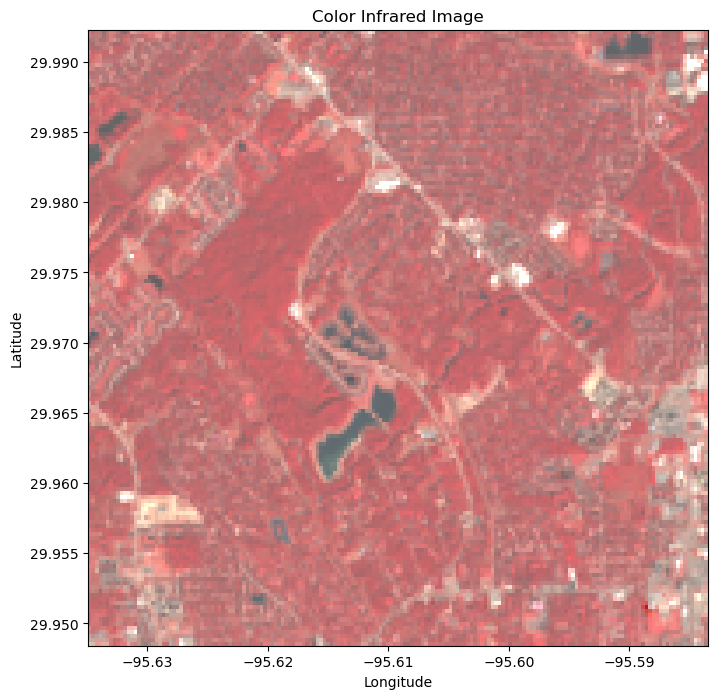

In [53]:
#2
plt.figure(figsize=(8, 8))

# Since we only have one band, NDWI, we don't need to use .sel().
# Notice that the vmin and vmax here are -1 and 1, since NDWI ranges from -1 to 1.
# I chose the cmap "Blues" because it is a commonly used color map for NDWI.
data_proj_clip.sel(band=['B5', 'B4', 'B3']).plot.imshow(vmin=0, vmax=20000)

# Add title and axis labels.
plt.title("Color Infrared Image")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

# This band combination is the Color Infrared combination, which allows us to see the NIR light reflected by plants.

In [54]:
#3
# NDWI = (Green – NIR) / (Green + NIR)
grn = data_proj_clip.sel(band="B3")
nir = data_proj_clip.sel(band="B5")

ndwi = (grn - nir)/(grn + nir)

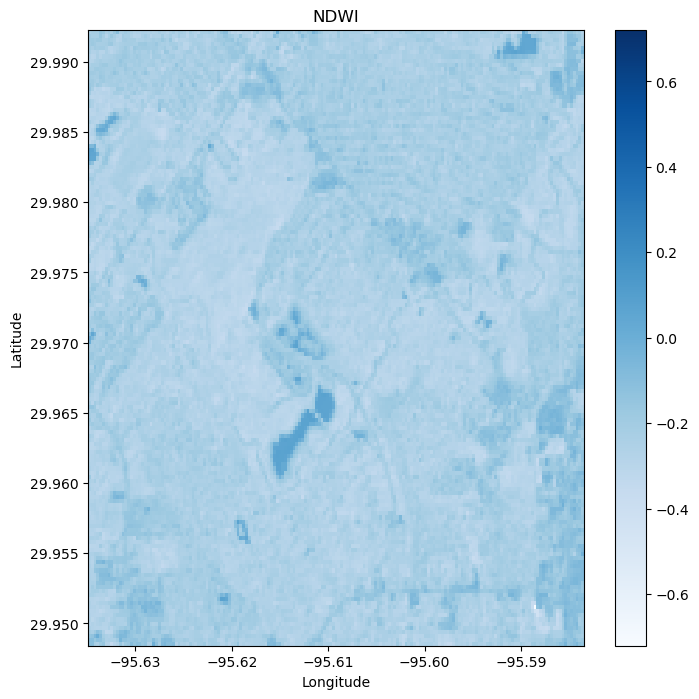

In [55]:
#4
plt.figure(figsize=(8, 8))

# Since we only have one band, NDWI, we don't need to use .sel().
# Notice that the vmin and vmax here are -1 and 1, since NDWI ranges from -1 to 1.
# I chose the cmap "Blues" because it is a commonly used color map for NDWI.
ndwi.plot.imshow(vmin=ndwi.min(), vmax=-(ndwi.min()), cmap="Blues")

# Add title and axis labels.
plt.title("NDWI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [56]:
#5
ndwi.rio.to_raster(os.path.expanduser("~/ASC_students/ryan/advanced_packages/output/ndwi.tif"))